In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import re

# =========================
# PARAMÈTRES
# =========================
V0 = 2000  # µL

# volume total à chaque expérience
V_total = {"Exp1": 2000,"Exp2": 2008,"Exp3": 2016,"Exp4": 2024,"Exp5": 2032,"Exp6": 2040,"Exp7": 2048,"Exp8": 2056,"Exp9": 2064,"Exp10": 2079,
    "Exp11": 2094,"Exp12": 2109,"Exp13": 2124,"Exp14": 2154,"Exp15": 2184,"Exp16": 2214,"Exp17": 2244,"Exp18": 2274,}


def read_spectrum(file_path):
    df = pd.read_csv(file_path)

    # garder seulement les 2 colonnes utiles
    df = df.iloc[:, :2].copy()
    df.columns = ["Wavelength", "Intensity"]

    # enlever la ligne texte éventuelle
    df = df[df["Wavelength"] != "Wavelength (nm)"]

    # conversion numérique
    df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")
    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")

    # supprimer NaN
    df = df.dropna()

    return df

def exp_number(filename):
    match = re.search(r"Exp(\d+)", filename)
    return int(match.group(1)) if match else 0

# =========================
# CHARGEMENT DES DONNÉES
# =========================
buffer = read_spectrum("Buffer_excitation_277nm_spectra _285nm_380nm.csv")

exp_files = glob.glob("Exp*_excitation_277nm_spectra _285nm_380nm.csv")
exp_files = sorted(exp_files, key=exp_number)

processed = []

for file in exp_files:
    name = os.path.basename(file).replace("_excitation_277nm_spectra _285nm_380nm.csv", "")
    df = read_spectrum(file)

    # 1) correction de dilution
    dilution_factor = V_total[name] / V0
    df["Intensity_dilution_corrected"] = df["Intensity"] * dilution_factor

    # 2) soustraction du blanc
    df["Intensity_blank_subtracted"] = (df["Intensity_dilution_corrected"].values - buffer["Intensity"].values)

    # 3) normalisation
    max_val = df["Intensity_blank_subtracted"].max()
    if max_val != 0:
        df["Intensity_normalized"] = df["Intensity_blank_subtracted"] / max_val
    else:
        df["Intensity_normalized"] = df["Intensity_blank_subtracted"]

    df["Experiment"] = name

    processed.append((name, df))

Graphe brut

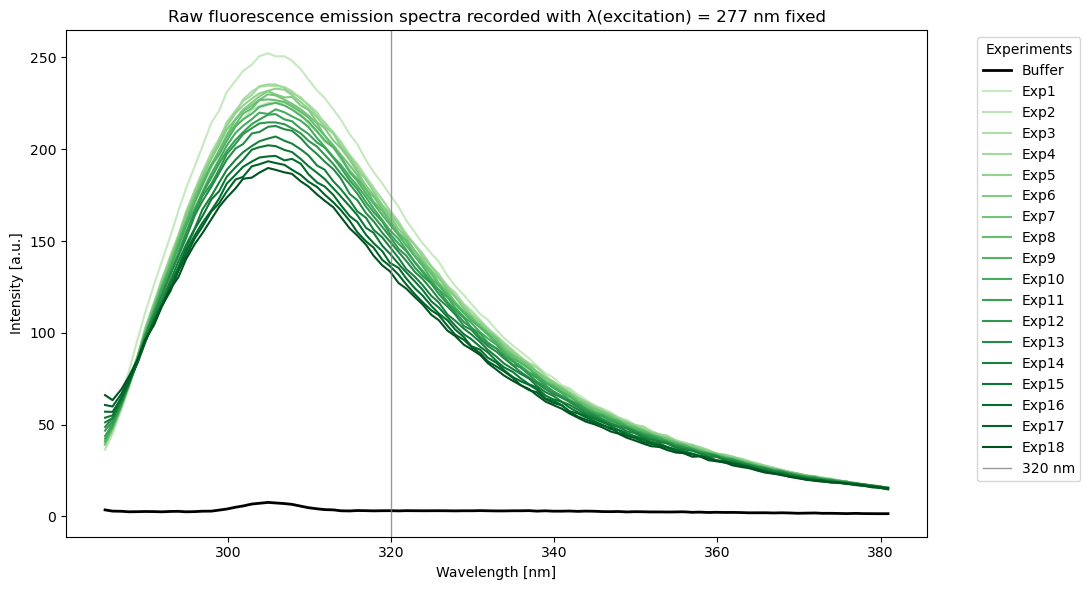

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))


colors = plt.cm.Greens(np.linspace(0.25, 0.95, len(processed)))

# Buffer
ax.plot(
    buffer["Wavelength"],
    buffer["Intensity"],
    color="black",
    lw=2,
    label="Buffer"
)

# Spectres bruts
for (name, df), color in zip(processed, colors):
    ax.plot(
        df["Wavelength"],
        df["Intensity"],
        color=color,
        lw=1.5,
        label=name
    )

ax.axvline(x=320, color="gray", lw=1, alpha=0.8, label="320 nm")
ax.set_title("Raw fluorescence emission spectra recorded with λ(excitation) = 277 nm fixed")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity [a.u.]")
ax.legend(title="Experiments", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Graphe corrigé dilution + blanc

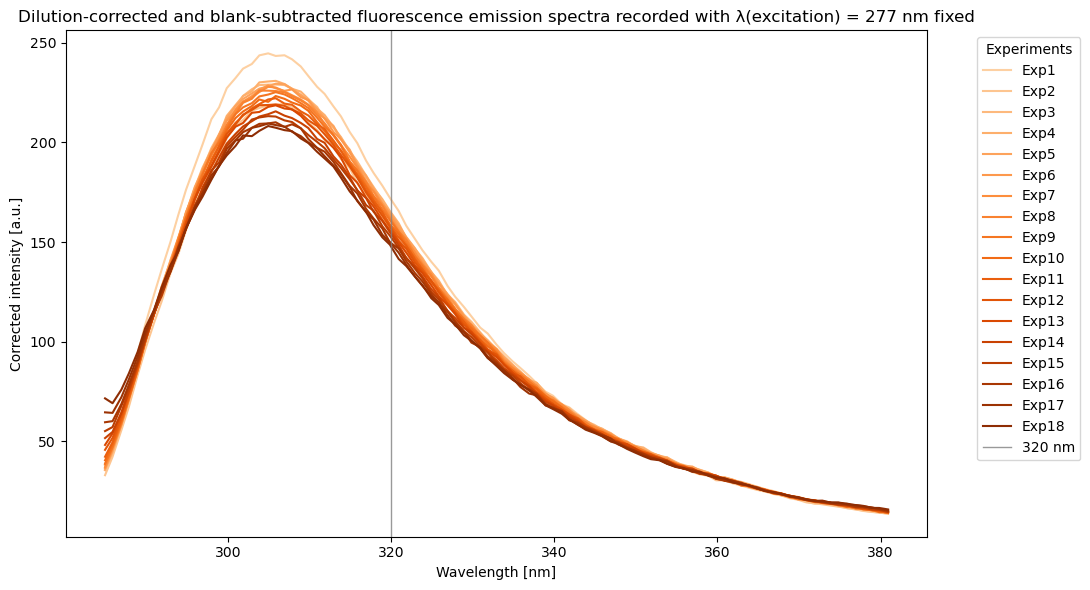

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))


colors = plt.cm.Oranges(np.linspace(0.25, 0.95, len(processed)))

for (name, df), color in zip(processed, colors):
    ax.plot(
        df["Wavelength"],
        df["Intensity_blank_subtracted"],
        color=color,
        lw=1.5,
        label=name
    )

ax.axvline(x=320, color="gray", lw=1, alpha=0.8, label="320 nm")
ax.set_title("Dilution-corrected and blank-subtracted fluorescence emission spectra recorded with λ(excitation) = 277 nm fixed")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Corrected intensity [a.u.]")
ax.legend(title="Experiments", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Graphe normalisé

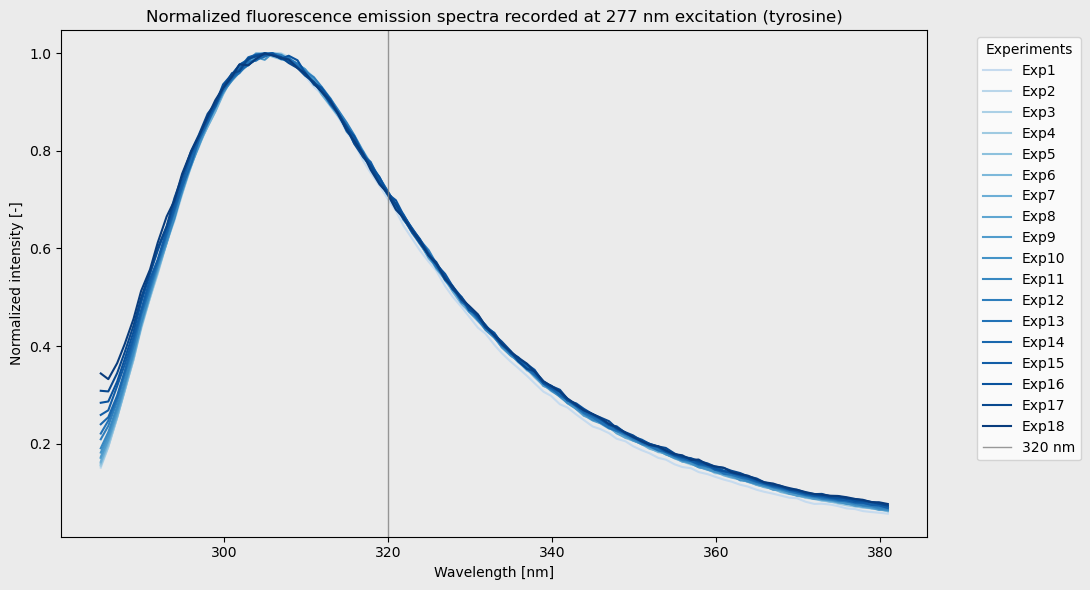

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("0.92")
ax.set_facecolor("0.92")

colors = plt.cm.Blues(np.linspace(0.25, 0.95, len(processed)))

for (name, df), color in zip(processed, colors):
    ax.plot(
        df["Wavelength"],
        df["Intensity_normalized"],
        color=color,
        lw=1.5,
        label=name
    )

ax.axvline(x=320, color="grey", lw=1, alpha=0.8, label="320 nm")
ax.set_title("Normalized fluorescence emission spectra recorded at 277 nm excitation (tyrosine)")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Normalized intensity [-]")
ax.legend(title="Experiments", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()




===== Hill fit results =====
Chosen wavelength = 305.48 nm


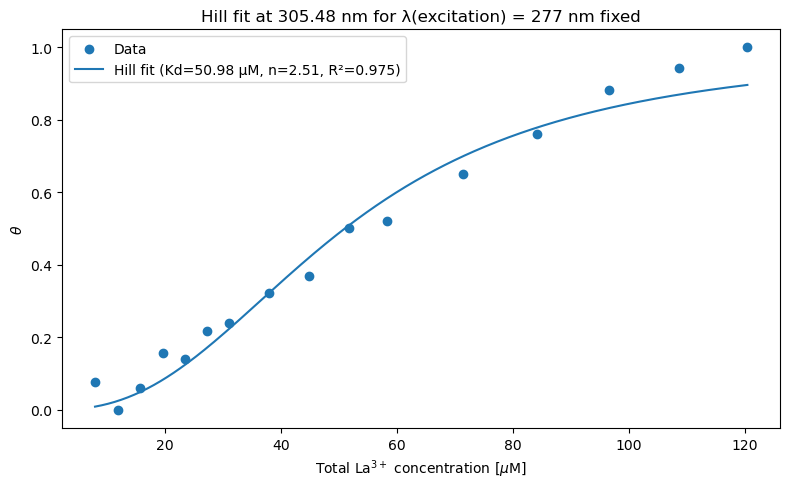

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# 1) PARAMETRES EXPERIMENTAUX
# =========================================================
V0_uL = 2000.0
C_La_stock = 1.0e-3

V_total_uL = {
    "Exp1": 2000, "Exp2": 2008, "Exp3": 2016, "Exp4": 2024,
    "Exp5": 2032, "Exp6": 2040, "Exp7": 2048, "Exp8": 2056,
    "Exp9": 2064, "Exp10": 2079, "Exp11": 2094, "Exp12": 2109,
    "Exp13": 2124, "Exp14": 2154, "Exp15": 2184, "Exp16": 2214,
    "Exp17": 2244, "Exp18": 2274,
}

V_added_uL = {
    "Exp1": 0, "Exp2": 8, "Exp3": 16, "Exp4": 24,
    "Exp5": 32, "Exp6": 40, "Exp7": 48, "Exp8": 56,
    "Exp9": 64, "Exp10": 79, "Exp11": 94, "Exp12": 109,
    "Exp13": 124, "Exp14": 154, "Exp15": 184, "Exp16": 214,
    "Exp17": 244, "Exp18": 274,
}

# =========================================================
# 2) ZONE DE RECHERCHE DU PIC
# =========================================================
lambda_min = 285
lambda_max = 380

# =========================================================
# 3) LONGUEUR D'ONDE EXPERIMENTALE
#    -> avec les intensités corrigées non normalisées
# =========================================================
lambda_maxima = []

for name, df in processed:
    sub = df[(df["Wavelength"] >= lambda_min) & (df["Wavelength"] <= lambda_max)].copy()
    idx_max = sub["Intensity_blank_subtracted"].idxmax()
    lambda_peak = sub.loc[idx_max, "Wavelength"]
    lambda_maxima.append(lambda_peak)

lambda_exp = np.mean(lambda_maxima)

# =========================================================
# 4) EXTRACTION DE L’INTENSITE CORRIGEE A lambda_exp
# =========================================================
exp_names = []
I_lambda = []
La_total_M = []

for name, df in processed:
    idx_nearest = (df["Wavelength"] - lambda_exp).abs().idxmin()
    intensity_value = df.loc[idx_nearest, "Intensity_blank_subtracted"]

    C_La_tot = C_La_stock * (V_added_uL[name] / V_total_uL[name])

    exp_names.append(name)
    I_lambda.append(intensity_value)
    La_total_M.append(C_La_tot)

I_lambda = np.array(I_lambda, dtype=float)[2:]
La_total_M = np.array(La_total_M, dtype=float)[2:]

# =========================================================
# 5) THETA
#    Si le signal corrigé augmente avec [La3+] :
#        theta = (I - Imin)/(Imax - Imin)
#    Si le signal corrigé diminue avec [La3+] :
#        theta = (Imax - I)/(Imax - Imin)
# =========================================================
def theta_from_intensity(I_values, increasing=True):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de calculer theta.")

    if increasing:
        theta = (I_values - Imin) / (Imax - Imin)
    else:
        theta = (Imax - I_values) / (Imax - Imin)

    return theta

# Mettre increasing=False si le signal diminue avec [La3+]
theta = theta_from_intensity(I_lambda, increasing=False)

# =========================================================
# 6) OUTLIERS
#    -> visibles sur le graphe mais exclus du fit et du R²
# =========================================================
outlier_names = {}  

fit_mask = (np.array([name not in outlier_names for name in exp_names[2:]])
            & np.isfinite(La_total_M)& np.isfinite(theta)& (La_total_M > 0))

outlier_mask = np.array([name in outlier_names for name in exp_names])

L_fit = La_total_M[fit_mask]
theta_fit = theta[fit_mask]

# =========================================================
# 7) MODELE DE HILL
# =========================================================
def hill_model(L, Kd, n):
    L = np.asarray(L, dtype=float)
    return (L**n) / (Kd**n + L**n)

idx0 = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0 = float(L_fit[idx0])
n0 = 2.0

params, cov = curve_fit(hill_model,L_fit,theta_fit,p0=[Kd0, n0],bounds=([1e-12, 0.1], [1e-2, 20.0]),maxfev=20000)

Kd_fit, n_fit = params

# =========================================================
# 8) R²
#    -> calculé uniquement sur les points utilisés dans le fit
# =========================================================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)

ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

print("\n===== Hill fit results =====")
print(f"Chosen wavelength = {lambda_exp:.2f} nm")

# =========================================================
# 9) PLOT
# =========================================================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 400)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure(figsize=(8, 5))

# Tous les points expérimentaux
plt.scatter(La_total_M * 1e6, theta, label="Data", zorder=3)

# Courbe de fit
plt.plot(L_curve * 1e6,theta_curve,label=f"Hill fit (Kd={Kd_fit*1e6:.2f} µM, n={n_fit:.2f}, R²={R2:.3f})")

plt.xlabel(r"Total La$^{3+}$ concentration [$\mu$M]")
plt.ylabel(r"$\theta$")
plt.title(f"Hill fit at {lambda_exp:.2f} nm for λ(excitation) = 277 nm fixed")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 10) AFFICHAGE DES VALEURS
# =========================================================
for name, L, Icorr, th in zip(exp_names, La_total_M, I_lambda, theta):
    print(name, L * 1e6, Icorr, th)

Note : le premier et le second point n'ont pas été pris en compte 
